# Full Two-Stage Drone Detection & Classification Demo

Complete pipeline: YOLOv8 detects drones → EfficientNet-B0 classifies drone types

**10 Drone Types:** Cinewhoop, DJI FPV, DJI Mavic, DJI Phantom, Fixed wing, Hexacopter, Octocopter, Pluto Mini Drone, Quadcopter, VTOL

## 1. Imports

In [9]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import cv2
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO
from torchvision import transforms
from torchvision.models import efficientnet_b0

print("✓ Imports complete")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

✓ Imports complete
PyTorch: 2.8.0
CUDA: False


## 2. Load Detection Model (Stage 1)

In [10]:
detector = YOLO("../models/checkpoints/drone_detection_minimal/weights/best.pt")
print(f"✓ Detector loaded")
print(f"  Classes: {detector.names}")

✓ Detector loaded
  Classes: {0: 'drone', 1: 'not-drone'}


## 3. Load Classification Model (Stage 2)

In [11]:
# Load checkpoint
checkpoint = torch.load("../models/checkpoints/drone_classifier/best.pt", 
                       map_location='cpu', weights_only=False)

class_names = checkpoint['class_names']
num_classes = checkpoint['num_classes']

print(f"✓ Classifier loaded")
print(f"  Val acc: {checkpoint['best_val_acc']:.1f}%")
print(f"  Test acc: {checkpoint['test_acc']:.1f}%")
print(f"  Classes: {', '.join(class_names)}")

# Create model
classifier = efficientnet_b0(weights=None)
classifier.classifier[1] = nn.Linear(classifier.classifier[1].in_features, num_classes)
classifier.load_state_dict(checkpoint['model_state_dict'])
classifier.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classifier = classifier.to(device)
print(f"  Device: {device}")

✓ Classifier loaded
  Val acc: 89.3%
  Test acc: 90.9%
  Classes: Cinewhoop, DJI FPV, DJI Mavic, DJI Phantom, Fixed wing, Hexacopter, Octocopter, Pluto Mini Drone, Quadcopter, VTOL
  Device: cpu


## 4. Setup Preprocessing

In [12]:
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
print("✓ Preprocessing ready")

✓ Preprocessing ready


## 5. Two-Stage Pipeline Function

In [13]:
def two_stage_inference(image_path, detector, classifier, preprocess, class_names,
                       detection_conf=0.25, classification_conf=0.3, device='cpu'):
    # Read image
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    
    # Stage 1: Detect
    results = detector.predict(image_path, conf=detection_conf, verbose=False)[0]
    
    detections = []
    for box in results.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        
        det = {
            'bbox': [x1, y1, x2, y2],
            'detection_class': detector.names[cls_id],
            'detection_conf': conf,
            'drone_type': None,
            'classification_conf': None,
            'top3': []
        }
        
        # Stage 2: Classify ONLY if class is 'drone' (not 'not-drone')
        if detector.names[cls_id] == 'drone' and conf >= classification_conf:
            crop = image[max(0,y1):min(h,y2), max(0,x1):min(w,x2)]
            if crop.size > 0:
                crop_tensor = preprocess(crop).unsqueeze(0).to(device)
                with torch.no_grad():
                    out = classifier(crop_tensor)
                    probs = torch.softmax(out, dim=1)[0]
                    conf_cls, pred = probs.max(0)
                
                det['drone_type'] = class_names[pred.item()]
                det['classification_conf'] = conf_cls.item()
                
                top3_probs, top3_idx = probs.topk(3)
                det['top3'] = [(class_names[i.item()], p.item()) 
                              for i, p in zip(top3_idx, top3_probs)]
        
        detections.append(det)
    
    return {'image': image, 'detections': detections, 
            'path': str(image_path), 'size': (w, h)}

print("✓ Pipeline function ready")

✓ Pipeline function ready


## 6. Visualization Function

In [14]:
def visualize(result, show_top3=False):
    colors = {
        'Cinewhoop': '#FF6B6B', 'DJI FPV': '#4ECDC4', 'DJI Mavic': '#45B7D1',
        'DJI Phantom': '#96CEB4', 'Fixed wing': '#FFEAA7', 'Hexacopter': '#DFE6E9',
        'Octocopter': '#74B9FF', 'Pluto Mini Drone': '#A29BFE', 
        'Quadcopter': '#FD79A8', 'VTOL': '#FDCB6E'
    }
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(result['image'])
    
    for det in result['detections']:
        x1, y1, x2, y2 = det['bbox']
        cls = det['detection_class']
        dtype = det['drone_type']
        
        # Color and style based on detection
        if cls == 'not-drone':
            color = '#E74C3C'
            linestyle = '--'
            linewidth = 2
            label = f"NOT DRONE\n{det['detection_conf']:.1%}"
        elif dtype:
            color = colors.get(dtype, '#00B894')
            linestyle = '-'
            linewidth = 3
            label = f"{dtype}\n{det['classification_conf']:.1%}"
        else:
            color = '#636E72'
            linestyle = '-'
            linewidth = 3
            label = f"Drone\n{det['detection_conf']:.1%}"
        
        # Draw box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                linewidth=linewidth, edgecolor=color, 
                                facecolor='none', linestyle=linestyle)
        ax.add_patch(rect)
        
        # Draw label
        label_y = y1 - 10 if y1 > 50 else y2 + 10
        ax.text(x1, label_y, label,
               bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.8),
               fontsize=11, fontweight='bold', color='white', va='bottom')
        
        # Top 3 predictions
        if show_top3 and det['top3']:
            top3_text = "Top 3:\n" + "\n".join(
                [f"{i+1}. {n}: {p:.1%}" for i, (n, p) in enumerate(det['top3'])]
            )
            ax.text(x2+5, y1, top3_text,
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8),
                   fontsize=9, va='top')
    
    ax.axis('off')
    ax.set_title(f"Detected {len(result['detections'])} object(s) - {Path(result['path']).name}",
                fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    return fig

print("✓ Visualization ready")

✓ Visualization ready


## 7. Find Test Images

In [15]:
# Try test images first
test_dir = Path("../data/processed/drone-vs-bird-binary/test/images")
if not test_dir.exists():
    test_dir = Path("..")

test_images = list(test_dir.glob("*.jpg"))[:6]

if test_images:
    print(f"Found {len(test_images)} images:")
    for img in test_images:
        print(f"  - {img.name}")
else:
    print("⚠ No images found")

Found 6 images:
  - b-878-_png_jpg.rf.c3db65ce22c8f65427700465435204a1.jpg
  - youtube-162_jpg.rf.d38d9c6a4ef473e316c135bf7b12f022.jpg
  - b-444-_png_jpg.rf.ddee4f3446348e38463eafb581496c3f.jpg
  - cap-148-_png_jpg.rf.b8e826d94d941edf59bb47c0308dfab2.jpg
  - cap-168-_png_jpg.rf.1af588be578d7cbce127df2c7d867bff.jpg
  - b-510-_png_jpg.rf.c8247fb1576a59a82cdf574d8a9e3890.jpg


## 8. Run Pipeline on Images

In [16]:
results = []

for img_path in test_images:
    print(f"\nProcessing: {img_path.name}")
    
    result = two_stage_inference(
        img_path, detector, classifier, preprocess, class_names,
        detection_conf=0.25, classification_conf=0.3, device=device
    )
    results.append(result)
    
    print(f"  Detected {len(result['detections'])} object(s)")
    for i, det in enumerate(result['detections']):
        if det['drone_type']:
            print(f"    {i+1}. {det['drone_type']} ({det['classification_conf']:.1%})")
        else:
            print(f"    {i+1}. {det['detection_class']} ({det['detection_conf']:.1%})")

print(f"\n✓ Processed {len(results)} images")


Processing: b-878-_png_jpg.rf.c3db65ce22c8f65427700465435204a1.jpg
  Detected 1 object(s)
    1. DJI Phantom (60.0%)

Processing: youtube-162_jpg.rf.d38d9c6a4ef473e316c135bf7b12f022.jpg
  Detected 1 object(s)
    1. not-drone (73.7%)

Processing: b-444-_png_jpg.rf.ddee4f3446348e38463eafb581496c3f.jpg
  Detected 0 object(s)

Processing: cap-148-_png_jpg.rf.b8e826d94d941edf59bb47c0308dfab2.jpg
  Detected 1 object(s)
    1. DJI Phantom (87.0%)

Processing: cap-168-_png_jpg.rf.1af588be578d7cbce127df2c7d867bff.jpg
  Detected 1 object(s)
    1. DJI Phantom (90.8%)

Processing: b-510-_png_jpg.rf.c8247fb1576a59a82cdf574d8a9e3890.jpg
  Detected 1 object(s)
    1. DJI Phantom (32.2%)

✓ Processed 6 images


## 9. Visualize Results

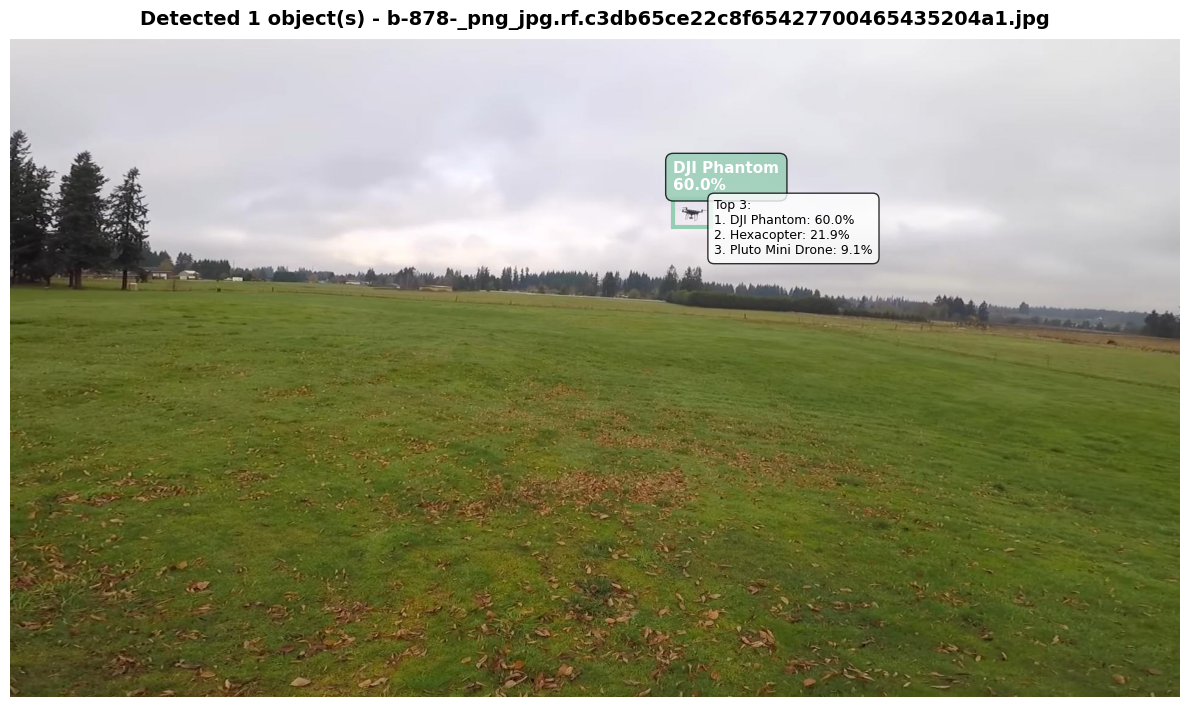


Image: b-878-_png_jpg.rf.c3db65ce22c8f65427700465435204a1.jpg

  Detection 1:
    Type: DJI Phantom
    Confidence: 59.99%
    Top 3:
      1. DJI Phantom: 59.99%
      2. Hexacopter: 21.91%
      3. Pluto Mini Drone: 9.12%



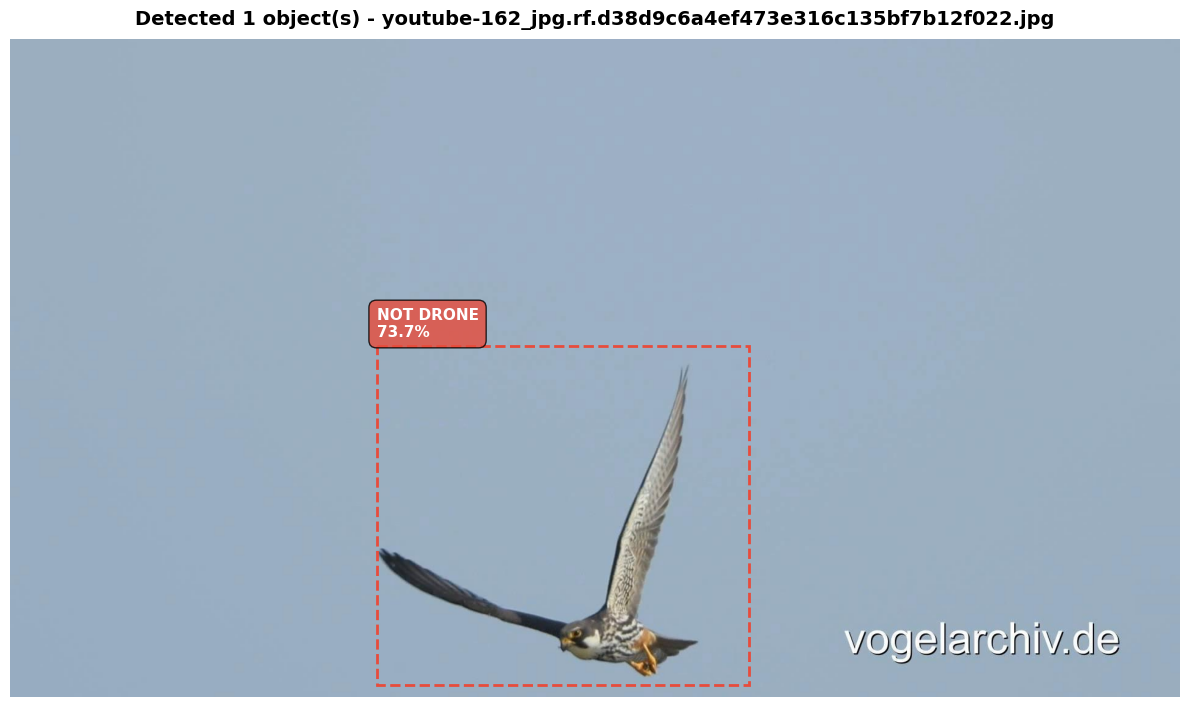


Image: youtube-162_jpg.rf.d38d9c6a4ef473e316c135bf7b12f022.jpg

  Detection 1:
    Class: not-drone
    Confidence: 73.68%



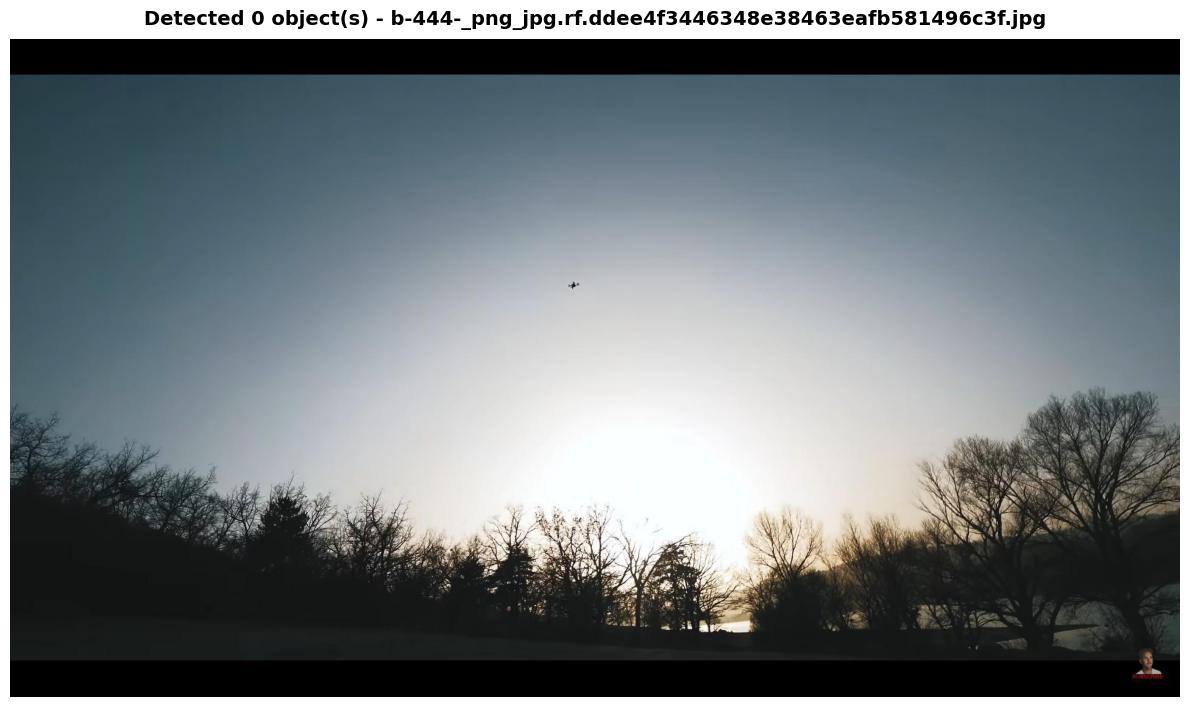


Image: b-444-_png_jpg.rf.ddee4f3446348e38463eafb581496c3f.jpg



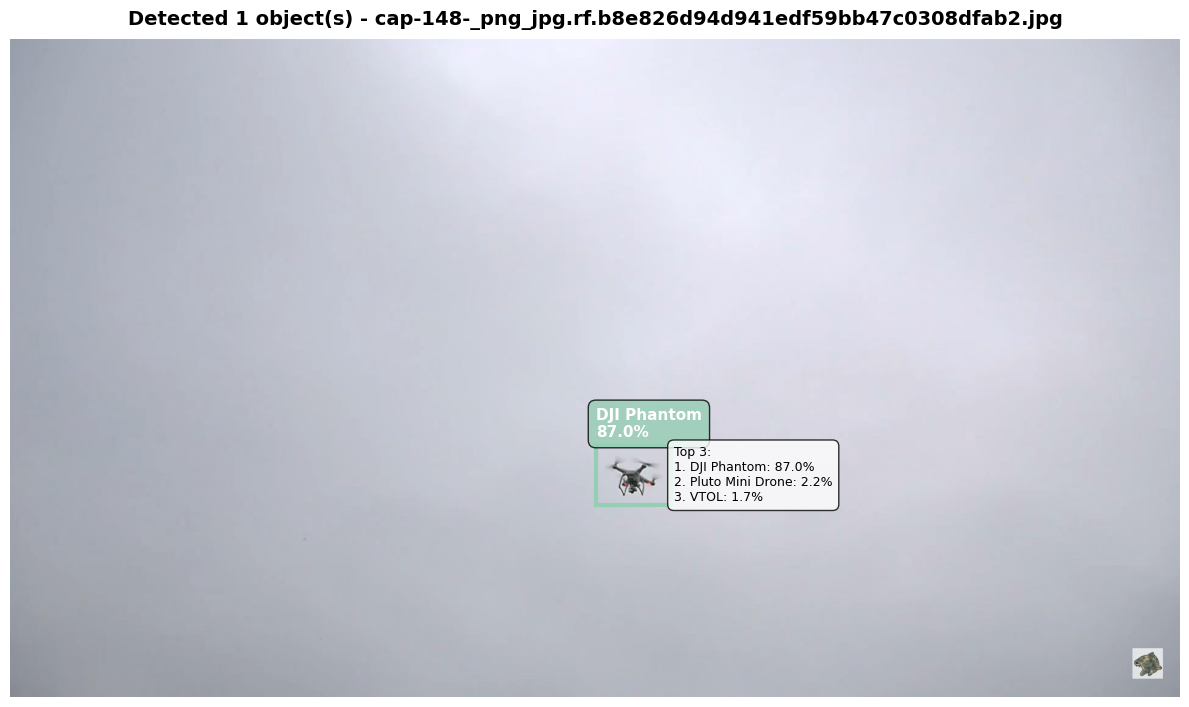


Image: cap-148-_png_jpg.rf.b8e826d94d941edf59bb47c0308dfab2.jpg

  Detection 1:
    Type: DJI Phantom
    Confidence: 86.99%
    Top 3:
      1. DJI Phantom: 86.99%
      2. Pluto Mini Drone: 2.15%
      3. VTOL: 1.71%



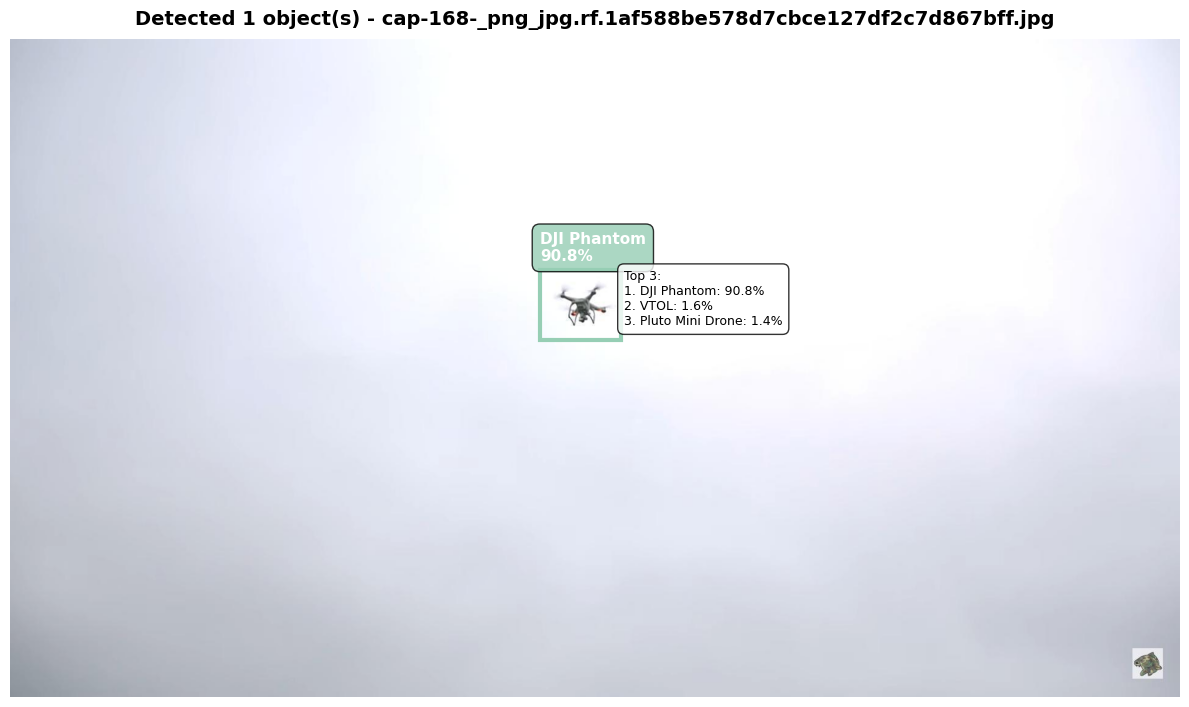


Image: cap-168-_png_jpg.rf.1af588be578d7cbce127df2c7d867bff.jpg

  Detection 1:
    Type: DJI Phantom
    Confidence: 90.80%
    Top 3:
      1. DJI Phantom: 90.80%
      2. VTOL: 1.62%
      3. Pluto Mini Drone: 1.38%



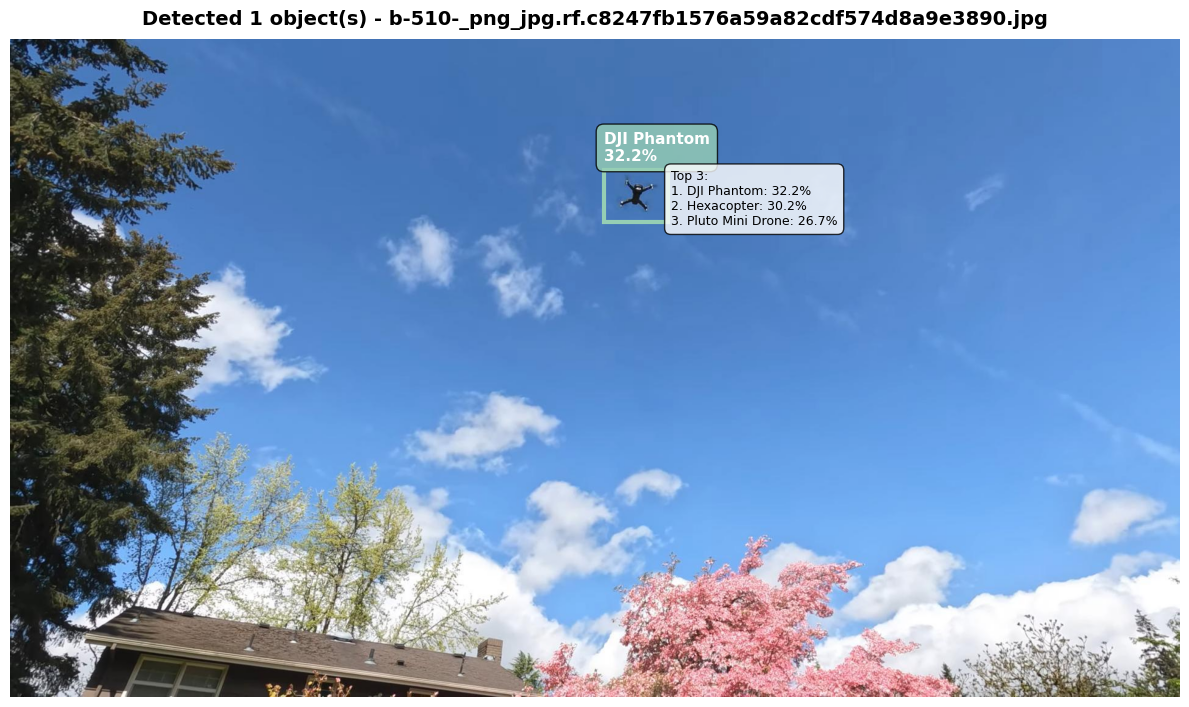


Image: b-510-_png_jpg.rf.c8247fb1576a59a82cdf574d8a9e3890.jpg

  Detection 1:
    Type: DJI Phantom
    Confidence: 32.24%
    Top 3:
      1. DJI Phantom: 32.24%
      2. Hexacopter: 30.25%
      3. Pluto Mini Drone: 26.67%



In [17]:
for result in results:
    fig = visualize(result, show_top3=True)
    plt.show()
    
    print(f"\nImage: {Path(result['path']).name}")
    for i, det in enumerate(result['detections']):
        print(f"\n  Detection {i+1}:")
        if det['drone_type']:
            print(f"    Type: {det['drone_type']}")
            print(f"    Confidence: {det['classification_conf']:.2%}")
            print(f"    Top 3:")
            for j, (name, prob) in enumerate(det['top3']):
                print(f"      {j+1}. {name}: {prob:.2%}")
        else:
            print(f"    Class: {det['detection_class']}")
            print(f"    Confidence: {det['detection_conf']:.2%}")
    print()

# Add paths to your custom images here

Processing custom images...

Processing: fpv.jpg


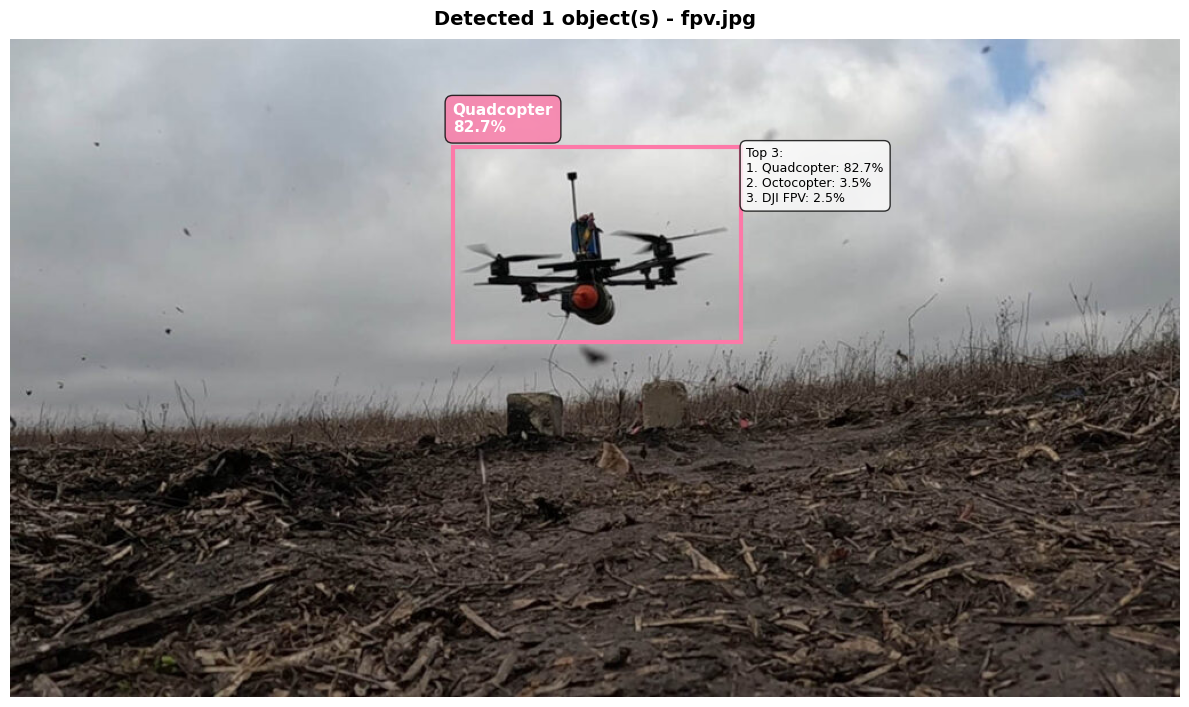

  Detection 1:
    Type: Quadcopter (82.73%)

Processing: fixed_wing.png


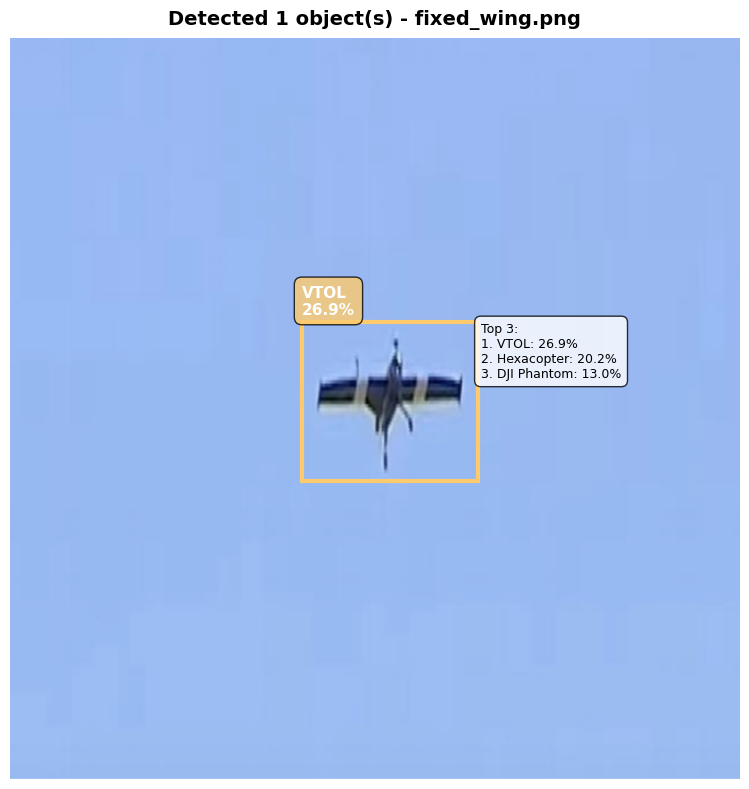

  Detection 1:
    Type: VTOL (26.90%)

Processing: octocopter.jpg


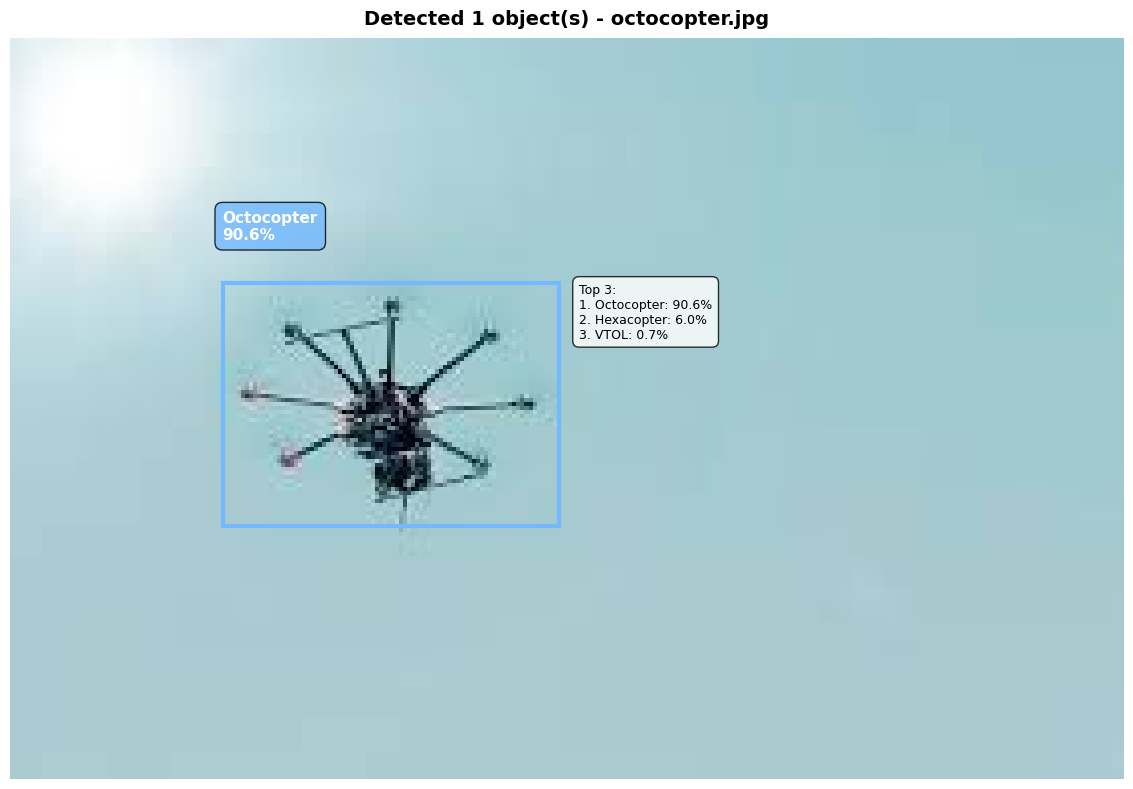

  Detection 1:
    Type: Octocopter (90.55%)



In [26]:
custom_images = [
    "../data/web_test_images/fpv.jpg",
    "../data/web_test_images/fixed_wing.png",
    "../data/web_test_images/octocopter.jpg"
]

print("Processing custom images...")
print()

for custom_image in custom_images:
    if Path(custom_image).exists():
        print(f"Processing: {Path(custom_image).name}")
        
        result = two_stage_inference(
            custom_image, detector, classifier, preprocess, class_names,
            detection_conf=0.25, classification_conf=0.3, device=device
        )
        
        fig = visualize(result, show_top3=True)
        plt.show()
        
        # Print details
        for i, det in enumerate(result['detections']):
            print(f"  Detection {i+1}:")
            if det['drone_type']:
                print(f"    Type: {det['drone_type']} ({det['classification_conf']:.2%})")
            else:
                print(f"    {det['detection_class']} ({det['detection_conf']:.2%})")
        print()
    else:
        print(f"⚠ Image not found: {custom_image}")
        print()